# 实验练习：用于手写数字识别的神经网络，多分类 

在本练习中，你将使用神经网络来识别手写数字0-9。


# 大纲
- [ 1 - Packages ](#1)
- [ 2 - ReLU Activation](#2)
- [ 3 - Softmax Function](#3)
  - [ Exercise 1](#ex01)
- [ 4 - Neural Networks](#4)
  - [ 4.1 Problem Statement](#4.1)
  - [ 4.2 Dataset](#4.2)
  - [ 4.3 Model representation](#4.3)
  - [ 4.4 Tensorflow Model Implementation](#4.4)
  - [ 4.5 Softmax placement](#4.5)
    - [ Exercise 2](#ex02)


_**注意：** 为防止自动评分器出错，不允许编辑或删除此笔记本中的非评分单元格。也请不要添加任何新单元格。 
**一旦你通过了此作业** 并想尝试任何非评分代码，可以按照本笔记本底部的说明操作。_

<a name="1"></a>
## 1 - 包 

首先，让我们运行下面的单元格来导入本作业中需要的所有包。
- [numpy](https://numpy.org/) 是Python科学计算的基础包。
- [matplotlib](http://matplotlib.org) 是Python中用于绘制图形的流行库。
- [tensorflow](https://www.tensorflow.org/) 是流行的机器学习平台。

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import linear, relu, sigmoid
%matplotlib widget
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

from public_tests import * 

from autils import *
from lab_utils_softmax import plt_softmax
np.set_printoptions(precision=2)

I0000 00:00:1781450490.934503   49597 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781450490.972095   49597 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781450492.189392   49597 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


<a name="2"></a>
## 2 - ReLU 激活函数
本周介绍了一种新的激活函数，修正线性单元（ReLU）。 
$$ a = max(0,z) \quad\quad\text {# ReLU 函数} $$

W0000 00:00:1781450493.913583   49597 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 2/Practice Labs/autils.py:36: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  fig.tight_layout(pad=0.2)
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 2/Practice Labs/autils.py:36: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  fig.tight_layout(pad=0.2)
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 2/Practice Labs/autils.py:36: UserWarning: Glyph 28608 (\N{CJK UNIFIED IDEOGRAPH-6FC0}) missing from f

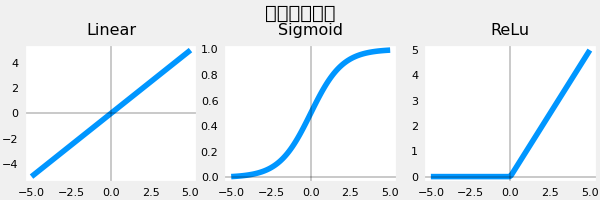

In [2]:
plt_act_trio()

<img align="right" src="./images/C2_W2_ReLu.png"     style=" width:380px; padding: 10px 20px; " >
右边讲座中的示例展示了ReLU的应用。在这个例子中，派生的"感知"特征不是二值的，而是具有连续的值范围。sigmoid最适合开/关或二值情况。ReLU提供连续的线性关系。此外，它还有一个输出为零的'关闭'范围。     
"关闭"特性使ReLU成为非线性激活函数。为什么需要这样？这使得多个单元能够在不相互干扰的情况下对结果函数做出贡献。这在可选的支持实验中有更详细的研究。

<a name="3"></a>
## 3 - Softmax 函数
多分类神经网络生成N个输出。选择一个输出作为预测答案。在输出层中，向量 $\mathbf{z}$ 由线性函数生成，然后输入到softmax函数。softmax函数将 $\mathbf{z}$ 转换为概率分布，如下所述。应用softmax后，每个输出将在0到1之间，输出之和为1。它们可以解释为概率。softmax的较大输入将对应较大的输出概率。
<center>  <img  src="./images/C2_W2_NNSoftmax.PNG" width="600" />  

softmax函数可以写成：
$$a_j = \frac{e^{z_j}}{ \sum_{k=0}^{N-1}{e^{z_k} }} \tag{1}$$

其中 $z = \mathbf{w} \cdot \mathbf{x} + b$，N是输出层中的特征/类别数。  

<a name="ex01"></a>
### 练习 1
让我们创建一个NumPy实现：

In [3]:
# UNQ_C1
# 评分单元格：my_softmax

def my_softmax(z):  
    """ Softmax将值向量转换为概率分布。
    参数：
      z (ndarray (N,))  : 输入数据，N个特征
    返回：
      a (ndarray (N,))  : z的softmax
    """    
    ### START CODE HERE ### 
    exp_z = np.exp(z) 
    a = exp_z / np.sum(exp_z)
    ### END CODE HERE ### 
    return a

In [4]:
z = np.array([1., 2., 3., 4.])
a = my_softmax(z)
atf = tf.nn.softmax(z)
print(f"my_softmax(z):         {a}")
print(f"tensorflow softmax(z): {atf}")

# BEGIN UNIT TEST  
test_my_softmax(my_softmax)
# END UNIT TEST  

my_softmax(z):         [0.03 0.09 0.24 0.64]
tensorflow softmax(z): [0.03 0.09 0.24 0.64]
 所有测试通过.


<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
    一种实现使用for循环首先构建分母，然后使用第二个循环计算每个输出。
    
```python
def my_softmax(z):  
    N = len(z)
    a =                     # initialize a to zeros 
    ez_sum =                # initialize sum to zero
    for k in range(N):      # loop over number of outputs             
        ez_sum +=           # sum exp(z[k]) to build the shared denominator      
    for j in range(N):      # loop over number of outputs again                
        a[j] =              # divide each the exp of each output by the denominator   
    return(a)
```
<details>
  <summary><font size="3" color="darkgreen"><b>点击获取代码</b></font></summary>
   
```python
def my_softmax(z):  
    N = len(z)
    a = np.zeros(N)
    ez_sum = 0
    for k in range(N):                
        ez_sum += np.exp(z[k])       
    for j in range(N):                
        a[j] = np.exp(z[j])/ez_sum   
    return(a)

或者，向量化实现：

def my_softmax(z):  
    ez = np.exp(z)              
    a = ez/np.sum(ez)           
    return(a)

```


下面，改变 `z` 输入的值。特别注意分子中的指数如何放大值之间的微小差异。还要注意输出值之和为1。

/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')


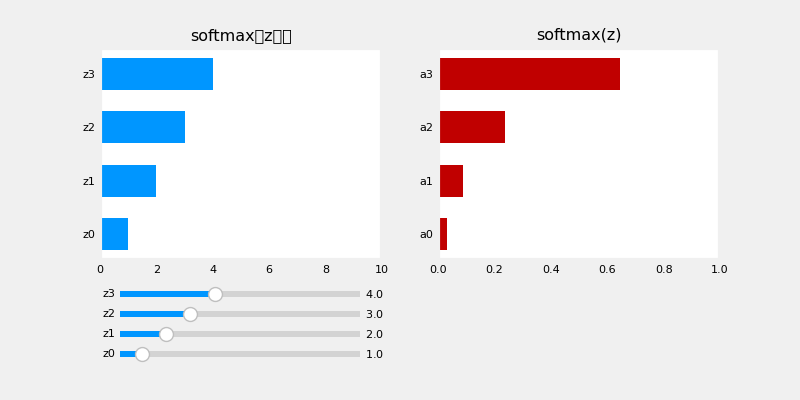

In [5]:
plt.close("all")
plt_softmax(my_softmax)

<a name="4"></a>
## 4 - 神经网络

在上周的作业中，你实现了一个神经网络来进行二分类。本周你将把它扩展到多分类。这将利用softmax激活。


<a name="4.1"></a>
### 4.1 问题陈述

在本练习中，你将使用神经网络来识别十个手写数字，0-9。这是一个多分类任务，需要从n个选项中选择一个。自动手写数字识别今天被广泛使用 - 从识别信封上的邮政编码到识别银行支票上的金额。 


<a name="4.2"></a>
### 4.2 数据集

你将首先加载此任务的数据集。 
- 下面显示的 `load_data()` 函数将数据加载到变量 `X` 和 `y` 中


- 该数据集包含5000个手写数字训练样本 $^1$。  

    - 每个训练样本是一个20像素 x 20像素的灰度图像。 
        - 每个像素由一个浮点数表示，表示该位置的灰度强度。 
        - 20 x 20的像素网格被"展开"成一个400维向量。 
        - 每个训练样本成为我们数据矩阵 `X` 中的一行。 
        - 这给了我们一个5000 x 400的矩阵 `X`，其中每一行是一个手写数字图像的训练样本。

$$X = 
\left(\begin{array}{cc} 
--- (x^{(1)}) --- \\
--- (x^{(2)}) --- \\
\vdots \\ 
--- (x^{(m)}) --- 
\end{array}\right)$$ 

- 训练集的第二部分是一个5000 x 1维向量 `y`，包含训练集的标签
    - 如果图像是数字 `0`，则 `y = 0`；如果图像是数字 `4`，则 `y = 4`，依此类推。

$^1$<sub> 这是MNIST手写数字数据集的子集 (http://yann.lecun.com/exdb/mnist/)</sub>

In [6]:
# 加载数据集
X, y = load_data()

#### 4.2.1 查看变量
让我们更熟悉你的数据集。  
- 一个好的起点是打印出每个变量，看看它包含什么。

下面的代码打印变量 `X` 和 `y` 的第一个元素。  

In [7]:
print ('The first element of X is: ', X[0])

The first element of X is:  [ 0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  8.56e-06  1.94e-06 -7.37e-04
 -8.13e-03 -1.86e-02 -1.87e-02 -1.88e-02 -1.91e-02 -1.64e-02 -3.78e-03
  3.30e-04  1.28e-05  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  1.16e-04  1.20e-04 -1.40e-02 -2.85e-02  8.04e-02
  2.67e-01  2.74e-01  2.79e-01  2.74e-01  2.25e-0

In [8]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  9


#### 4.2.2 检查变量的维度

另一种熟悉数据的方法是查看其维度。请打印 `X` 和 `y` 的形状，看看数据集中有多少训练样本。

In [9]:
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))

The shape of X is: (5000, 400)
The shape of y is: (5000, 1)


#### 4.2.3 可视化数据

你将从可视化训练集的一个子集开始。 
- 在下面的单元格中，代码从 `X` 中随机选择64行，将每行映射回20像素 x 20像素的灰度图像，并一起显示这些图像。 
- 每个图像的标签显示在图像上方

/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')


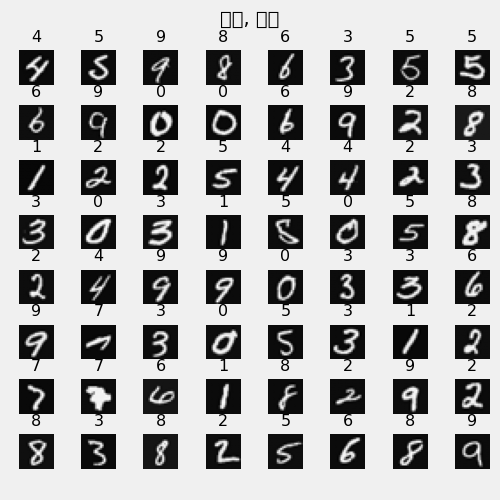

In [10]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# 你不需要修改此单元格中的任何内容

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]

#fig.tight_layout(pad=0.5)
widgvis(fig)
for i,ax in enumerate(axes.flat):
    # 选择随机索引
    random_index = np.random.randint(m)
    
    # 选择对应随机索引的行并
    # 重塑图像
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # 显示图像
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # 在图像上方显示标签
    ax.set_title(y[random_index,0])
    ax.set_axis_off()
    fig.suptitle("标签, 图像", fontsize=14)

<a name="4.3"></a>
### 4.3 模型表示

你将在本作业中使用的神经网络如下图所示。 
- 它有两个带有ReLU激活的密集层，后跟一个带有线性激活的输出层。 
    - 回忆一下，我们的输入是数字图像的像素值。
    - 由于图像大小为 $20\times20$，这给了我们 $400$ 个输入  
    
<img src="images/C2_W2_Assigment_NN.png" width="600" height="450">

- 参数的维度是为具有 $25$ 个单元的第1层、$15$ 个单元的第2层和 $10$ 个输出单元的第3层（每个数字一个）的神经网络设计的。

    - 回忆一下，这些参数的维度确定如下：
        - 如果网络某层有 $s_{in}$ 个单元，下一层有 $s_{out}$ 个单元，则 
            - $W$ 的维度为 $s_{in} \times s_{out}$。
            - $b$ 是一个包含 $s_{out}$ 个元素的向量
  
    - 因此，`W` 和 `b` 的形状为 
        - 第1层：`W1` 的形状为 (400, 25)，`b1` 的形状为 (25,)
        - 第2层：`W2` 的形状为 (25, 15)，`b2` 的形状为：(15,)
        - 第3层：`W3` 的形状为 (15, 10)，`b3` 的形状为：(10,)
>**注意：** 偏差向量 `b` 可以表示为1-D (n,) 或2-D (n,1) 数组。Tensorflow使用1-D表示，本实验将保持该约定：
               

<a name="4.4"></a>
### 4.4 Tensorflow模型实现


Tensorflow模型是逐层构建的。层的输入维度（上面的 $s_{in}$）会为你计算。你指定层的 *输出维度*，这决定了下一层的输入维度。第一层的输入维度由下面 `model.fit` 语句中指定的输入数据大小派生。 
>**注意：** 也可以添加一个指定第一层输入维度的输入层。例如：  
`tf.keras.Input(shape=(400,)),    #指定输入形状`  
我们将在包含它以说明一些模型大小调整。

<a name="4.5"></a>
### 4.5 Softmax放置位置
正如讲座和可选softmax实验中所述，如果在训练期间将softmax与损失函数分组而不是放在输出层中，数值稳定性会得到改善。这在 *构建* 模型和 *使用* 模型时都有影响。  
构建：  
* 最终的Dense层应使用 'linear' 激活。这实际上是不激活。 
* `model.compile` 语句将通过包含 `from_logits=True` 来表明这一点。
`loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True) `  
* 这不会影响目标的形式。对于SparseCategorialCrossentropy，目标是期望的数字，0-9。

使用模型：
* 输出不是概率。如果需要输出概率，请应用softmax函数。

<a name="ex02"></a>
### 练习 2

下面，使用Keras [Sequential模型](https://keras.io/guides/sequential_model/) 和带有ReLU激活的 [Dense层](https://keras.io/api/layers/core_layers/dense/) 来构建上述三层网络。

In [11]:
# UNQ_C2
# 评分单元格：Sequential模型
tf.random.set_seed(1234) # 以获得一致的结果
model = Sequential(
    [               
        ### START CODE HERE ### 
        tf.keras.Input(shape = (400,)),
        Dense(units = 25, activation = 'relu', name = 'layer1'),
        Dense(units = 15, activation = 'relu', name = 'layer2'),
        Dense(units = 10, activation = 'linear', name = 'layer3'),
        ### END CODE HERE ### 
    ], name = "my_model" 
)

In [12]:
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,575 (41.31 KB)

 Trainable params: 10,575 (41.31 KB)

 Non-trainable params: 0 (0.00 B)

<details>
  <summary><font size="3" color="darkgreen"><b>预期输出（点击展开）</b></font></summary>
`model.summary()` 函数显示了模型的有用摘要。注意，层的名称可能不同，因为它们是自动生成的，除非指定了名称。    
    
```
Model: "my_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
L1 (Dense)                   (None, 25)                10025     
_________________________________________________________________
L2 (Dense)                   (None, 15)                390       
_________________________________________________________________
L3 (Dense)                   (None, 10)                160       
=================================================================
Total params: 10,575
Trainable params: 10,575
Non-trainable params: 0
_________________________________________________________________
```

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
    
```python
tf.random.set_seed(1234)
model = Sequential(
    [               
        ### START CODE HERE ### 
        tf.keras.Input(shape=(400,)),     # @REPLACE 
        Dense(25, activation='relu', name = "L1"), # @REPLACE 
        Dense(15, activation='relu',  name = "L2"), # @REPLACE  
        Dense(10, activation='linear', name = "L3"),  # @REPLACE 
        ### END CODE HERE ### 
    ], name = "my_model" 
)
``` 

In [23]:
# BEGIN UNIT TEST     
test_model(model, 10, 400)
# END UNIT TEST     

所有测试通过!


摘要中显示的参数计数对应于权重和偏差数组中的元素数量，如下所示。

让我们进一步检查权重，以验证tensorflow产生了与我们上面计算相同的维度。

In [14]:
[layer1, layer2, layer3] = model.layers

In [15]:
#### 检查权重形状
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 10), b3 shape = (10,)


**预期输出**
```
W1 shape = (400, 25), b1 shape = (25,)  
W2 shape = (25, 15), b2 shape = (15,)  
W3 shape = (15, 10), b3 shape = (10,)
```

下面的代码：
* 定义损失函数 `SparseCategoricalCrossentropy`，并通过添加 `from_logits=True` 指示softmax应包含在损失计算中）
* 定义优化器。一个流行的选择是自适应动量（Adam），在讲座中有描述。

In [16]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)

history = model.fit(
    X,y,
    epochs=40
)

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 979us/step - loss: 1.6094
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6453 
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 0.4288
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - loss: 0.3413
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - loss: 0.2928
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - loss: 0.2594
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step - loss: 0.2340
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - loss: 0.2132
Epoch 9/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 0.1955
Epoch 10/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - loss: 0.1806
Epoch 11/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - loss: 0.1675
Epoch 12/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - loss: 0.1558
Epoch 13/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step - loss: 0.1451
Epoch 14/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - loss: 0.1358
Epoch 15/40
157/157 ━━━━━━━━━━

#### 轮次和批次
在上面的 `compile` 语句中，`epochs` 的数量设置为100。这指定整个数据集在训练期间应被应用100次。在训练期间，你会看到描述训练进度的输出，如下所示：
```
Epoch 1/100
157/157 [==============================] - 0s 1ms/step - loss: 2.2770
```
第一行 `Epoch 1/100` 描述了模型当前正在运行的轮次。为了效率，训练数据集被分成'批次'。Tensorflow中批次的默认大小是32。我们的数据集中有5000个样本，大约157个批次。第2行上的符号 `157/157 [====` 描述了已执行的批次。

#### 损失（代价）
在课程1中，我们学习了通过监控代价来跟踪梯度下降的进度。理想情况下，代价会随着算法迭代次数的增加而减少。Tensorflow将代价称为 `loss`。上面，你在 `model.fit` 执行时看到了每个轮次显示的损失。[.fit](https://www.tensorflow.org/api_docs/python/tf/keras/Model) 方法返回各种指标，包括损失。这被捕获在上面的 `history` 变量中。这可以用来在图中检查损失，如下所示。

/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 652

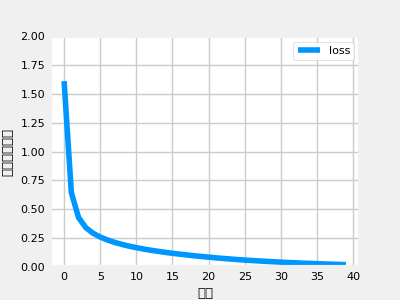

In [17]:
plot_loss_tf(history)

#### 预测 
要进行预测，请使用Keras的 `predict`。下面，X[1015] 包含一个数字2的图像。

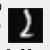

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
 predicting a Two: 
[[-13.4    4.38   7.01   1.59  -7.95 -10.43  -6.09  -2.97  -7.02  -5.59]]
 Largest Prediction index: 2


In [18]:
image_of_two = X[1015]
display_digit(image_of_two)

prediction = model.predict(image_of_two.reshape(1,400))  # prediction

print(f" predicting a Two: \n{prediction}")
print(f" Largest Prediction index: {np.argmax(prediction)}")

最大的输出是prediction[2]，表示预测的数字是'2'。如果问题只需要选择，这就足够了。使用NumPy的 [argmax](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) 来选择它。如果问题需要概率，则需要softmax：

In [19]:
prediction_p = tf.nn.softmax(prediction)

print(f" predicting a Two. Probability vector: \n{prediction_p}")
print(f"Total of predictions: {np.sum(prediction_p):0.3f}")

 predicting a Two. Probability vector: 
[[1.27e-09 6.71e-02 9.29e-01 4.14e-03 2.97e-07 2.48e-08 1.90e-06 4.30e-05
  7.52e-07 3.13e-06]]
Total of predictions: 1.000


要返回表示预测目标的整数，你需要最大概率的索引。这可以通过NumPy的 [argmax](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) 函数完成。

In [20]:
yhat = np.argmax(prediction_p)

print(f"np.argmax(prediction_p): {yhat}")

np.argmax(prediction_p): 2


让我们比较64个随机数字样本的预测与标签。这需要一些时间来运行。

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')


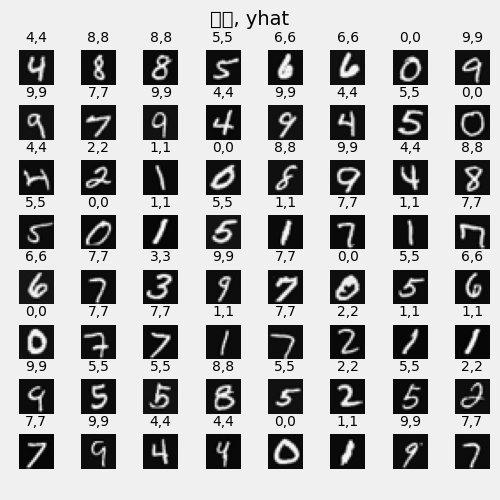

In [21]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# 你不需要修改此单元格中的任何内容

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]
widgvis(fig)
for i,ax in enumerate(axes.flat):
    # 选择随机索引
    random_index = np.random.randint(m)
    
    # 选择对应随机索引的行并
    # 重塑图像
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # 显示图像
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # 使用神经网络进行预测
    prediction = model.predict(X[random_index].reshape(1,400))
    prediction_p = tf.nn.softmax(prediction)
    yhat = np.argmax(prediction_p)
    
    # 在图像上方显示标签
    ax.set_title(f"{y[random_index,0]},{yhat}",fontsize=10)
    ax.set_axis_off()
fig.suptitle("标签, yhat", fontsize=14)
plt.show()

让我们看看一些错误。 
>注意：增加训练轮次可以消除此数据集上的错误。

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
12 errors out of 5000 images


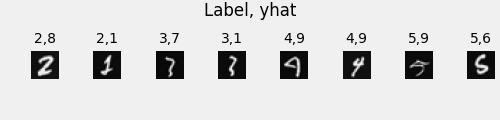

In [22]:
print( f"{display_errors(model,X,y)} errors out of {len(X)} images")

### 恭喜！
你已经成功构建并使用神经网络进行多分类。

<details>
  <summary><font size="2" color="darkgreen"><b>如果你想尝试任何非评分代码，请点击这里。</b></font></summary>
    <p><i><b>重要提示：请仅在你已经通过作业后才执行此操作，以避免自动评分器出现问题。</b></i>
    <ol>
        <li> 在笔记本菜单上，点击"视图" > "单元格工具栏" > "编辑元数据"</li>
        <li> 点击你想锁定/解锁的代码单元格旁边的"编辑元数据"按钮</li>
        <li> 将"editable"的属性值设置为：
            <ul>
                <li> 如果你想解锁，设置为 "true" </li>
                <li> 如果你想锁定，设置为 "false" </li>
            </ul>
        </li>
        <li> 在笔记本菜单上，点击"视图" > "单元格工具栏" > "无" </li>
    </ol>
    <p> 这是如何执行上述步骤的简短演示： 
        <br>
        <img src="https://drive.google.com/uc?export=view&id=14Xy_Mb17CZVgzVAgq7NCjMVBvSae3xO1" align="center" alt="unlock_cells.gif">
</details>